# 🏢 HR IBM Employee Attrition - ML Prediction

**Building a machine learning model to predict employee attrition using the IBM HR dataset.**


## ① Setup & Data Loading


**1.1** ❓ **Question:** What libraries and settings are needed for machine learning?


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math

# Machine Learning & Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, auc, roc_curve
from imblearn.over_sampling import SMOTE

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
%matplotlib inline

**1.2** 💡 **Insight:** We import pandas, matplotlib, seaborn, scikit-learn modules, and SMOTE for class imbalance handling.


**1.3** ❓ **Question:** How is the cleaned EDA dataset loaded?


In [36]:
df=pd.read_csv('../data/cleaned/EDA_HR_Employee_Attrition.csv')

**1.4** 💡 **Insight:** The cleaned HR dataset from EDA is loaded for ML preprocessing and modeling.


**1.5** ❓ **Question:** What does a random sample of records look like?


In [37]:
df.sample(3)

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
175,175,56,No,Travel_Rarely,713,Research & Development,8,3,Life Sciences,1,...,3,80,1,19,3,3,2,2,2,2
1241,1241,32,No,Travel_Rarely,371,Sales,19,3,Life Sciences,1,...,3,80,1,10,2,1,4,3,0,2
910,910,23,No,Travel_Rarely,373,Research & Development,1,2,Life Sciences,1,...,4,80,1,1,2,3,1,0,0,1


**1.6** 💡 **Insight:** Random sample shows representative employee records with all feature columns.


**1.7** ❓ **Question:** What feature columns are available?


In [38]:
df.columns

Index(['Unnamed: 0', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

**1.8** 💡 **Insight:** The dataset contains demographics, job role, compensation, and work-life balance features.


**1.9** ❓ **Question:** What does EmployeeCount contain?


In [39]:
df['EmployeeCount'].value_counts()

EmployeeCount
1    1470
Name: count, dtype: int64

**1.10** 💡 **Insight:** EmployeeCount is always 1 — a constant column with no predictive value.


**1.11** ❓ **Question:** What does StandardHours contain?


In [40]:
df['StandardHours'].value_counts()

StandardHours
80    1470
Name: count, dtype: int64

**1.12** 💡 **Insight:** StandardHours is always 8 — another constant redundant column.


## ② Data Cleaning


**2.1** ❓ **Question:** Which redundant columns are dropped?


In [41]:
redundant_cols = ['EmployeeCount', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[col for col in redundant_cols if col in df.columns])

**2.2** 💡 **Insight:** EmployeeCount, StandardHours, and EmployeeNumber are removed as they provide no predictive signal.


**2.3** ❓ **Question:** How is the attrition target encoded?


In [42]:
if df['Attrition'].dtype == 'O':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

**2.4** 💡 **Insight:** Attrition is mapped to binary: Yes=1 (left), No=0 (stayed).


**2.5** ❓ **Question:** What is the dataset shape after cleaning?


In [43]:
print(f"Dataset Shape after cleaning: {df.shape}")

Dataset Shape after cleaning: (1470, 32)


**2.6** 💡 **Insight:** The cleaned dataset has reduced dimensionality after removing redundant columns.


**2.7** ❓ **Question:** What does the cleaned data look like?


In [44]:
display(df.head())

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,...,3,1,0,8,0,1,6,4,0,5
1,1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,...,4,4,1,10,3,3,10,7,1,7
2,2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,...,3,2,0,7,3,3,0,0,0,0
3,3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,...,3,3,0,8,3,3,8,7,3,0
4,4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,3,4,1,6,3,3,2,2,2,2


**2.8** 💡 **Insight:** Cleaned data is ready for EDA and modeling steps ahead.


**2.9** ❓ **Question:** What are the dtypes and memory usage?


In [45]:
print(f"Dataset InFo: \n")
display(df.info())

Dataset InFo: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Attrition                 1470 non-null   int64 
 3   BusinessTravel            1470 non-null   object
 4   DailyRate                 1470 non-null   int64 
 5   Department                1470 non-null   object
 6   DistanceFromHome          1470 non-null   int64 
 7   Education                 1470 non-null   int64 
 8   EducationField            1470 non-null   object
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole 

None

**2.10** 💡 **Insight:** Data types and memory footprint are verified for correct preprocessing.


**2.11** ❓ **Question:** Are there any missing values?


In [46]:
print("\nMissing Values:")
print(df.isna().sum())


Missing Values:
Unnamed: 0                  0
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64


**2.12** 💡 **Insight:** Zero missing values — no imputation needed, simplifying the pipeline.


## ③ Exploratory Data Analysis


**3.1** ❓ **Question:** How is the attrition target distributed?


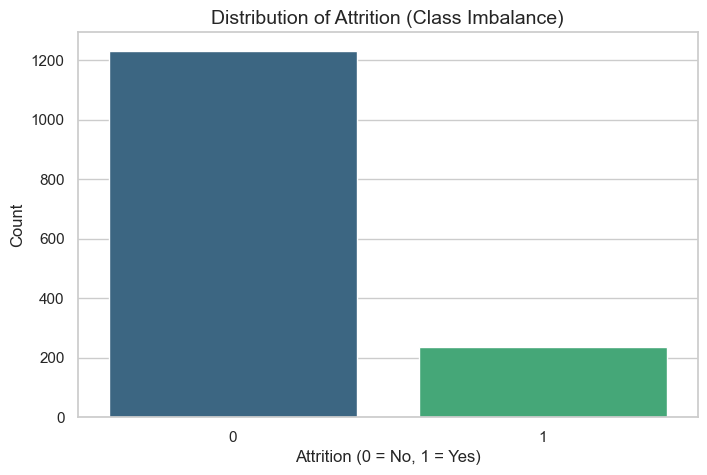

In [47]:
# Attrition Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title('Distribution of Attrition (Class Imbalance)', fontsize=14)
plt.xlabel('Attrition (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

**3.2** 💡 **Insight:** The data is imbalanced — significantly more stayers than leavers.


**3.3** ❓ **Question:** Which features correlate most with attrition?


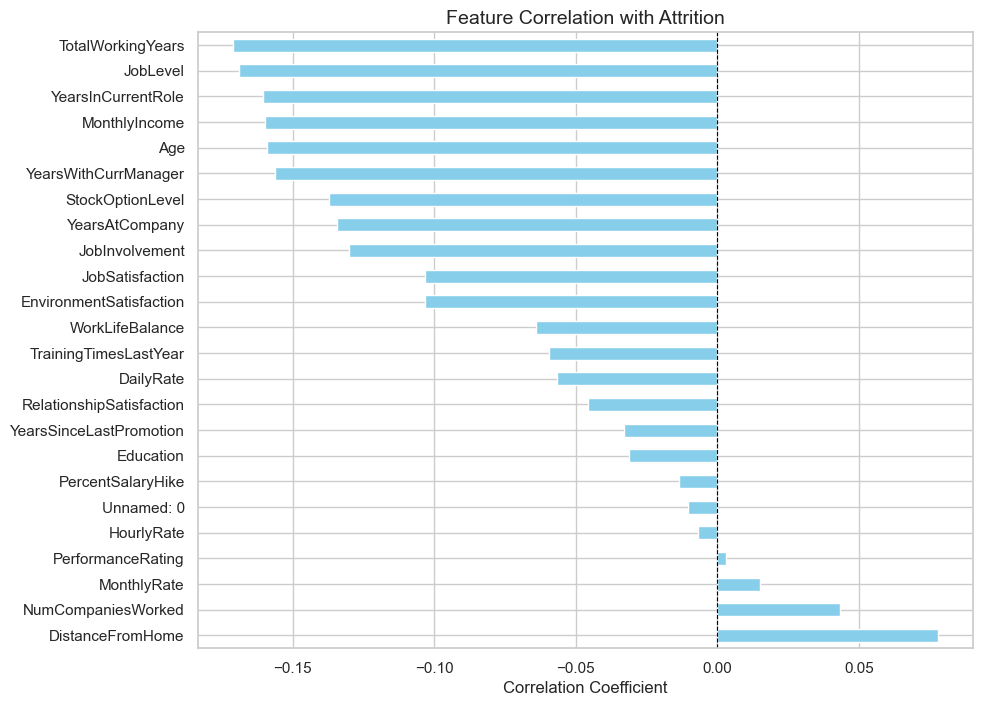

In [48]:
# Correlation with Target (Numerical Only)
plt.figure(figsize=(10, 8))

# Correlation calculation for numeric columns only
correlation_series =df.corr(numeric_only=True)['Attrition'].sort_values(ascending=False).drop('Attrition')

correlation_series.plot(kind='barh', color='skyblue')

plt.title('Feature Correlation with Attrition', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8) # إضافة خط الصفر للتمييز
plt.show()

**3.4** 💡 **Insight:** Positive correlation values increase attrition likelihood; negative values indicate retention.


**3.5** ❓ **Question:** How does attrition vary by gender?


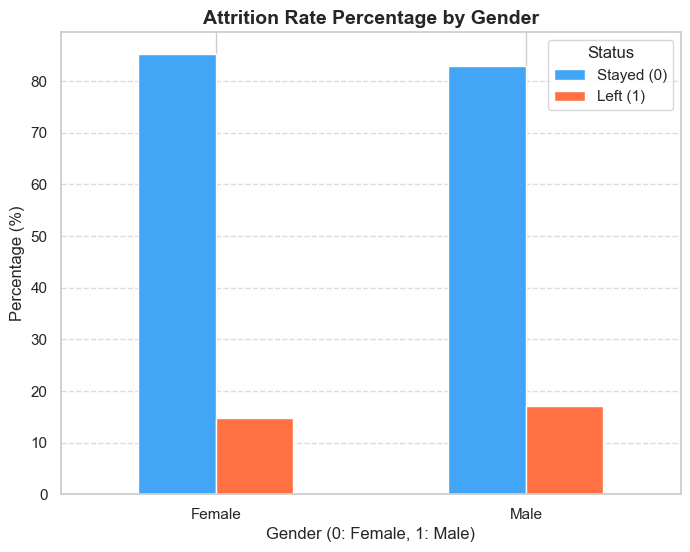

In [49]:
# Calculate percentages for visualization
gender_attrition = df.groupby('Gender')['Attrition'].value_counts(normalize=True).unstack() * 100

# Plotting
plt.figure(figsize=(8, 6))
gender_attrition.plot(kind='bar', stacked=False, color=['#42a5f5', '#ff7043'], ax=plt.gca())

plt.title('Attrition Rate Percentage by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender (0: Female, 1: Male)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(['Stayed (0)', 'Left (1)'], title='Status', loc='upper right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**3.6** 💡 **Insight:** Males have slightly higher attrition (~17%) than females (~14.8%), but the gap is small.


**3.7** ❓ **Question:** How does attrition vary across ages?


<Figure size 1400x600 with 0 Axes>

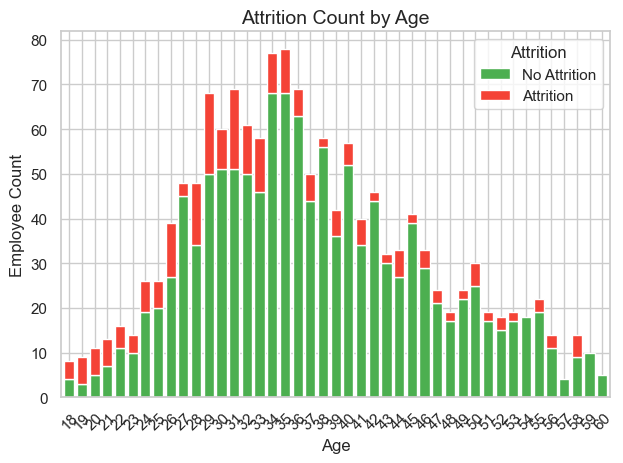

In [50]:
age_attrition = (
    df
    .groupby(['Age', 'Attrition'])
    .size()
    .unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(14, 6))
age_attrition.plot(
    kind='bar',
    stacked=True,
    color=['#4CAF50', '#F44336'],
    width=0.8
)

plt.title('Attrition Count by Age', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Employee Count')
plt.legend(['No Attrition', 'Attrition'], title='Attrition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**3.8** 💡 **Insight:** Employees in their 20s–30s face the highest attrition risk and should be retention priorities.


**3.9** ❓ **Question:** How does attrition vary by department?


<Figure size 1400x600 with 0 Axes>

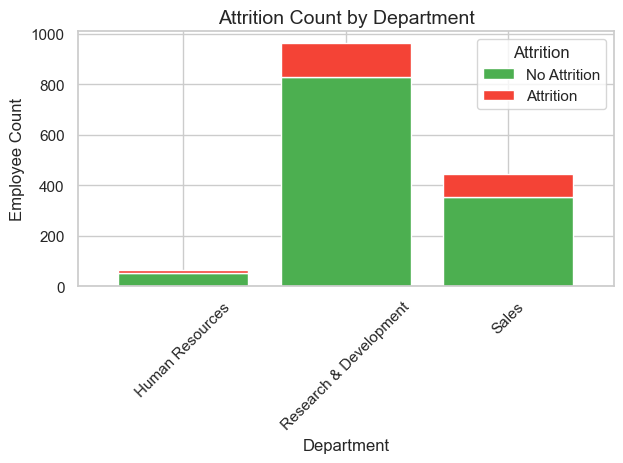

In [51]:
age_attrition = (
    df
    .groupby(['Department', 'Attrition'])
    .size()
    .unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(14, 6))
age_attrition.plot(
    kind='bar',
    stacked=True,
    color=['#4CAF50', '#F44336'],
    width=0.8
)

plt.title('Attrition Count by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Employee Count')
plt.legend(['No Attrition', 'Attrition'], title='Attrition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**3.10** 💡 **Insight:** Department 1 has the most employees and attrition cases; Department 0 has the least.


## ④ Preprocessing


**4.1** ❓ **Question:** What are the categorical columns?


In [52]:
df.select_dtypes(include='object').columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

**4.2** 💡 **Insight:** Categorical columns identified — these require label encoding for the ML model.


**4.3** ❓ **Question:** What are the numerical columns?


In [53]:
df.select_dtypes(include='number').columns

Index(['Unnamed: 0', 'Age', 'Attrition', 'DailyRate', 'DistanceFromHome',
       'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

**4.4** 💡 **Insight:** Numerical columns identified — these will be checked for outliers and scaling needs.


**4.5** ❓ **Question:** How are outliers detected in numerical features?


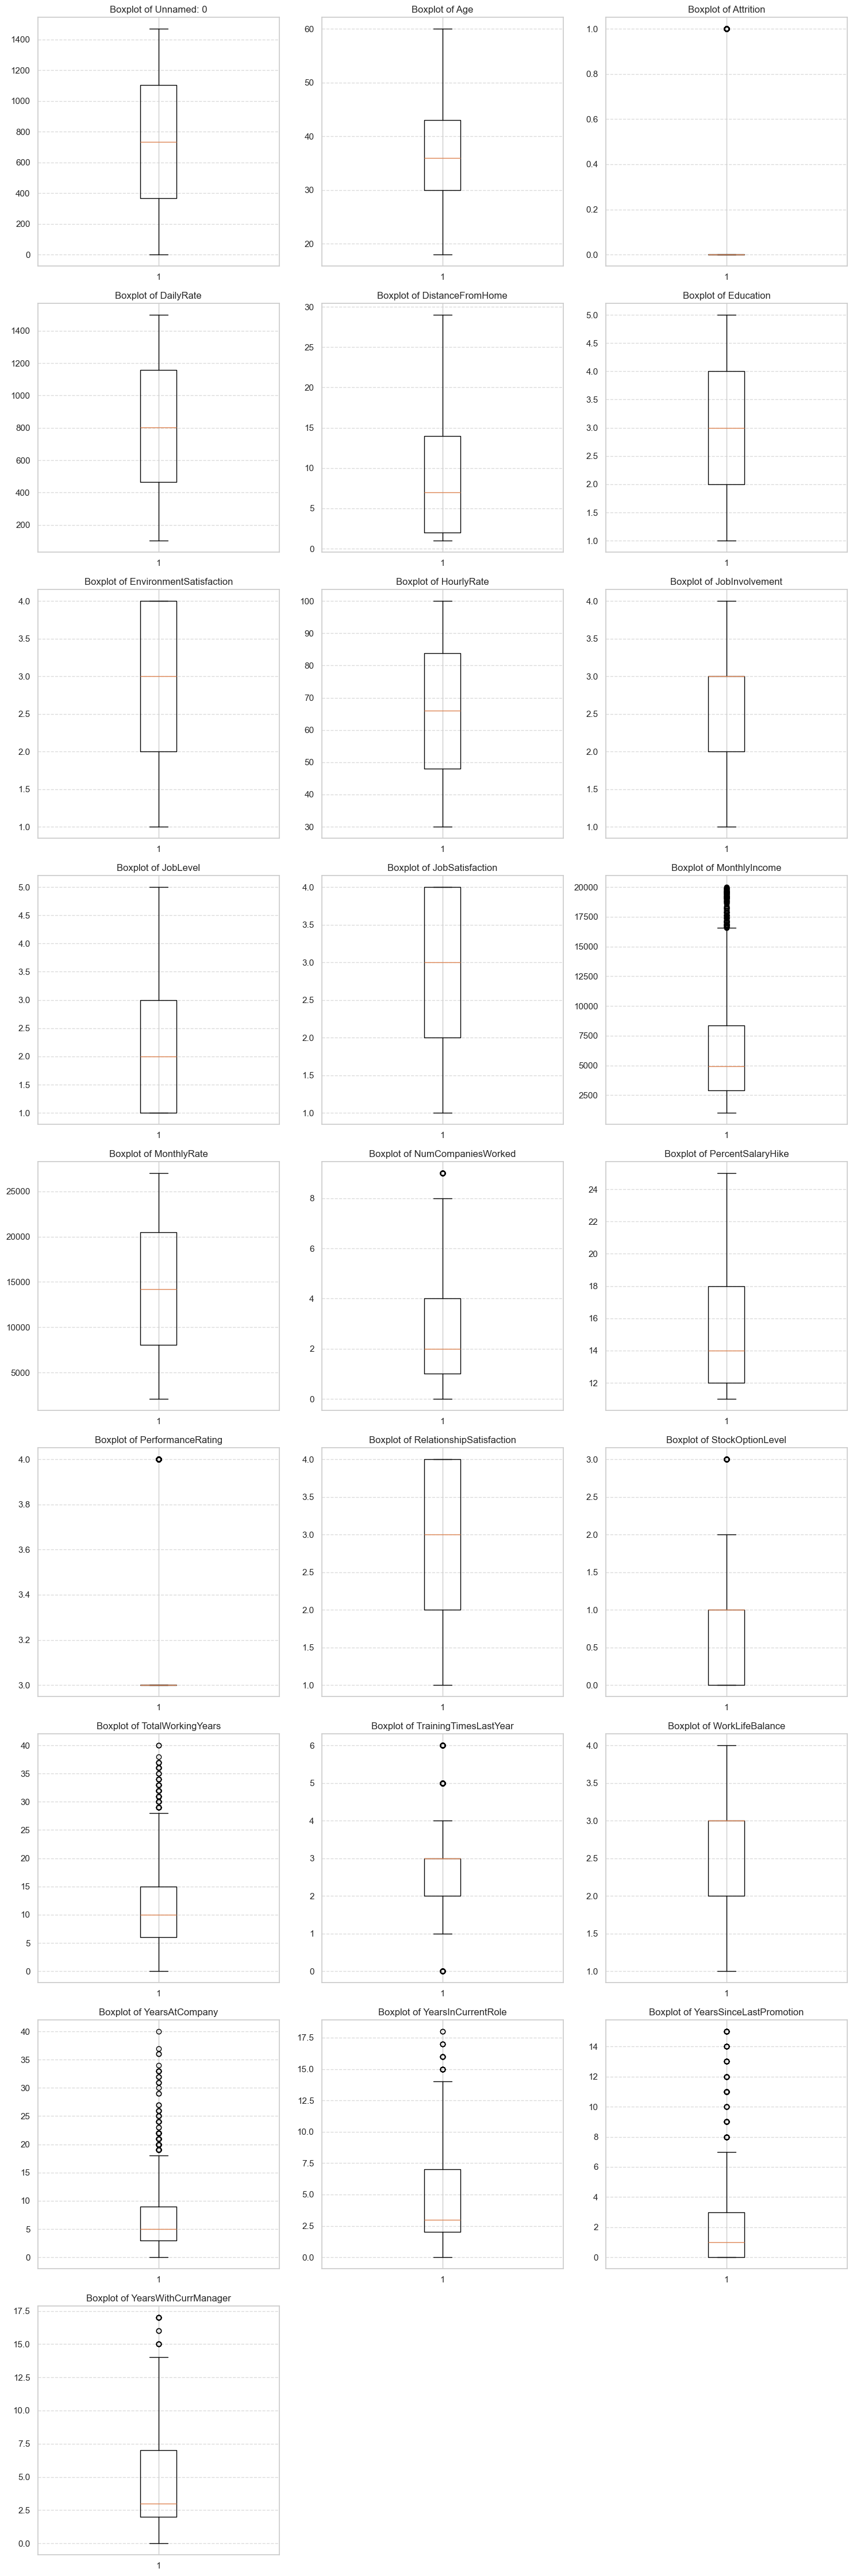

In [54]:
import matplotlib.pyplot as plt
import math

# Identify numerical columns
num_cols = df.select_dtypes(include='number').columns
n = len(num_cols)

# Define grid dimensions (e.g., 3 columns wide)
cols = 3
rows = math.ceil(n / cols)

# Create the figure
plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    plt.boxplot(df[col].dropna()) # Added .dropna() to prevent errors with missing values
    plt.title(f'Boxplot of {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Prevents titles from overlapping
plt.show()

**4.6** 💡 **Insight:** Boxplots visualize distributions and highlight outliers in each numerical column.


**4.7** ❓ **Question:** How are outliers handled using IQR?


In [55]:
for col in df.select_dtypes(include='number').columns:
    if col != 'Attrition':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower=lower, upper=upper)

**4.8** 💡 **Insight:** IQR-based clipping caps extreme values at computed bounds to reduce outlier impact.


**4.9** ❓ **Question:** How are categorical variables encoded?


In [56]:
labelmodel = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = labelmodel.fit_transform(df[col])

**4.10** 💡 **Insight:** LabelEncoder converts each categorical column into numeric values for model compatibility.


**4.11** ❓ **Question:** Why is Unnamed: 0 dropped?


In [57]:
df.drop('Unnamed: 0', axis=1, inplace=True)

**4.12** 💡 **Insight:** The index column from CSV export is unnecessary for modeling and is removed.


## ⑤ Train-Test Split & SMOTE


**5.1** ❓ **Question:** How are features and target separated?


In [58]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

**5.2** 💡 **Insight:** X holds all features; y holds the attrition binary target for supervised learning.


**5.3** ❓ **Question:** How is the data split for training and testing?


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**5.4** 💡 **Insight:** 80/20 stratified split preserves class distribution in both train and test sets.


**5.5** ❓ **Question:** How is class imbalance handled with SMOTE?


In [60]:
# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}


**5.6** 💡 **Insight:** SMOTE oversamples the minority class in training data, balancing classes for better model training.


## ⑥ Model Training & Evaluation


**6.1** ❓ **Question:** How are feature distributions visualized after resampling?


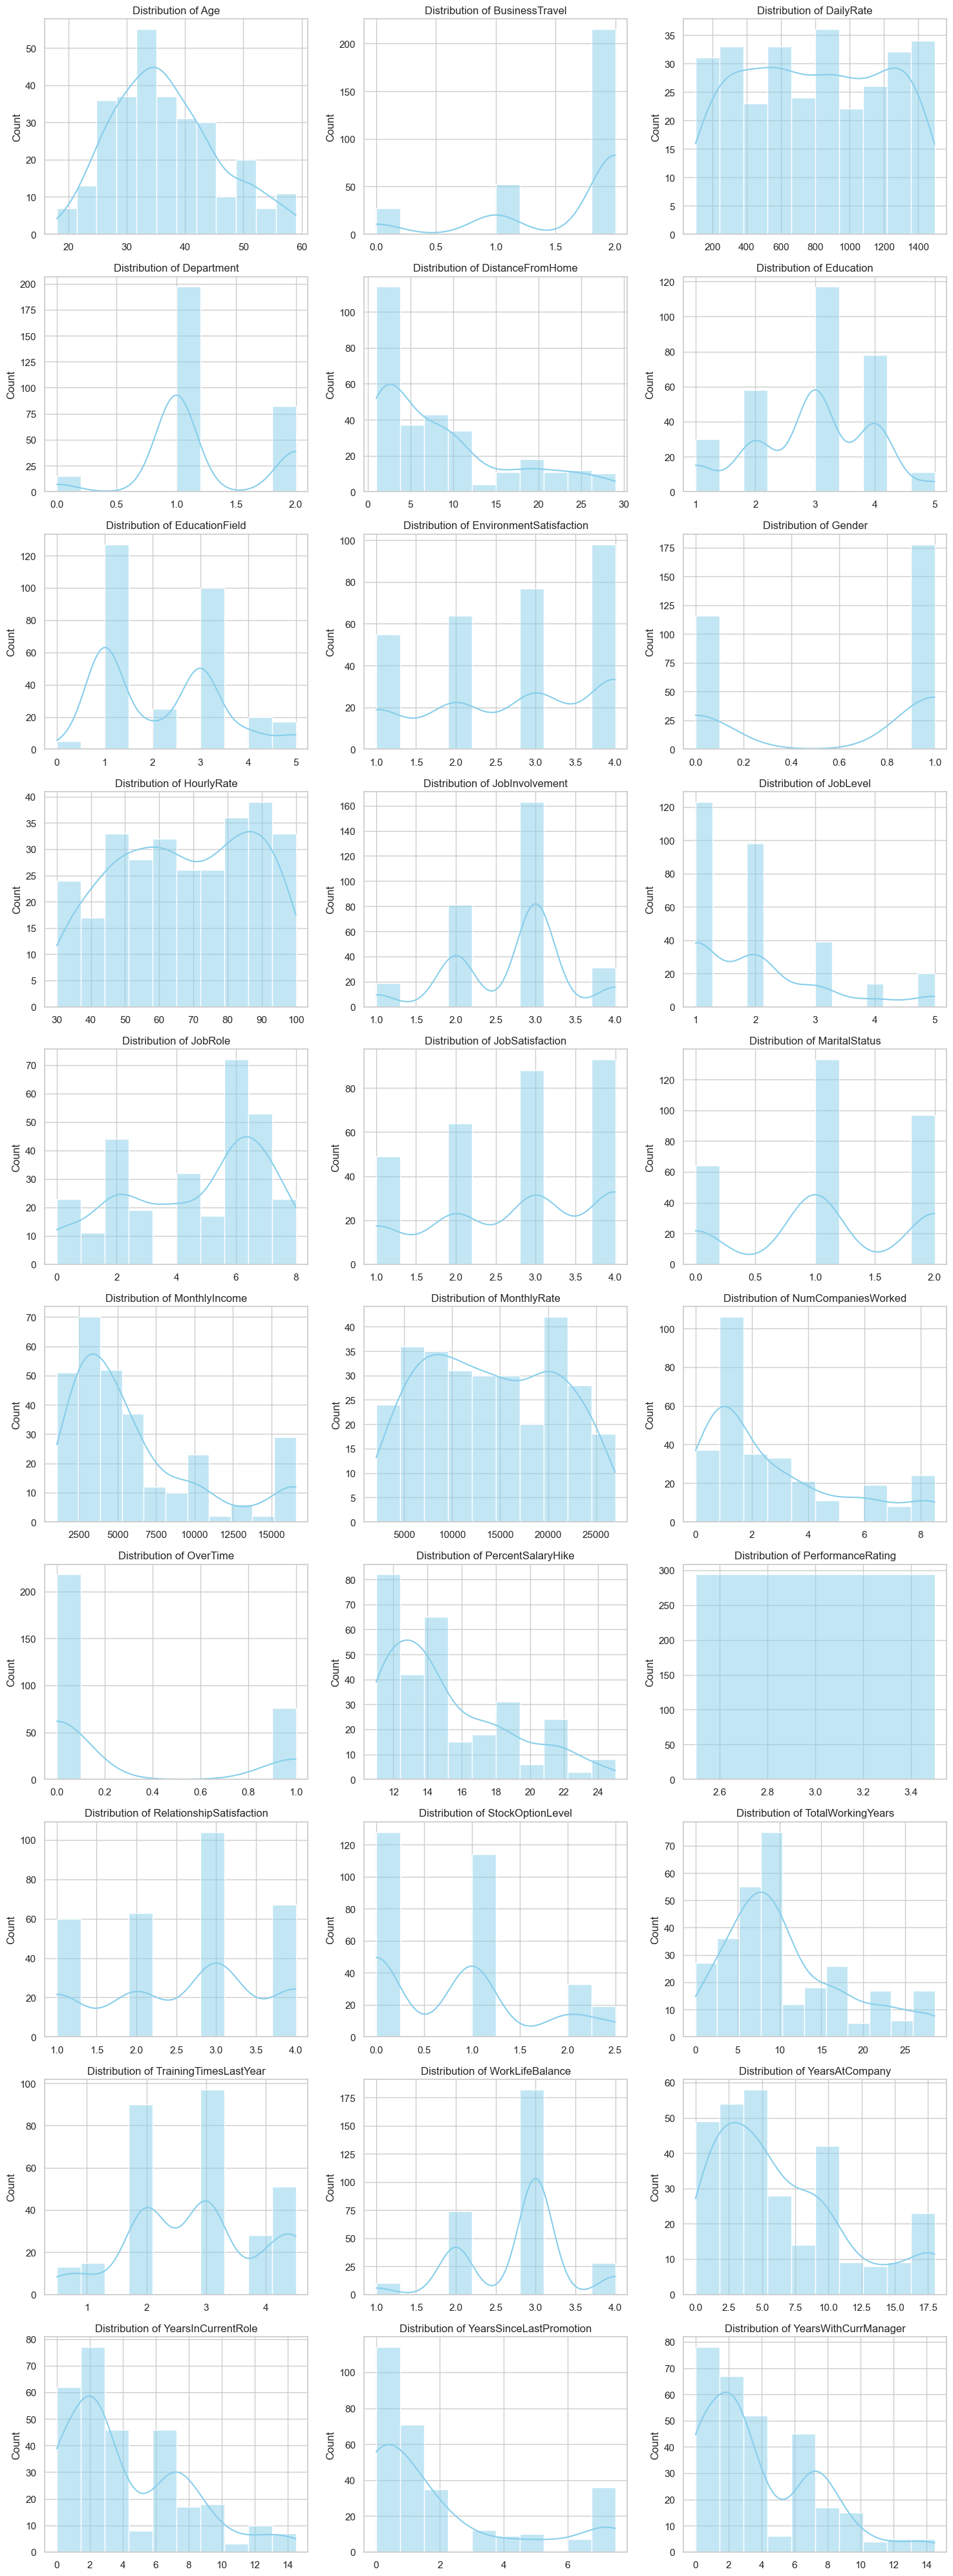

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Calculate the number of rows needed for the grid (assuming 3 columns)
num_features = len(X_test.columns)
cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten() # Flatten to iterate easily

for i, col in enumerate(X_test.columns):
    sns.histplot(X_test[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

# Remove any empty subplots if features don't fill the last row
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**6.2** 💡 **Insight:** A grid of histograms shows the distribution of all features after SMOTE balancing.


**6.3** ❓ **Question:** What does the correlation heatmap reveal?


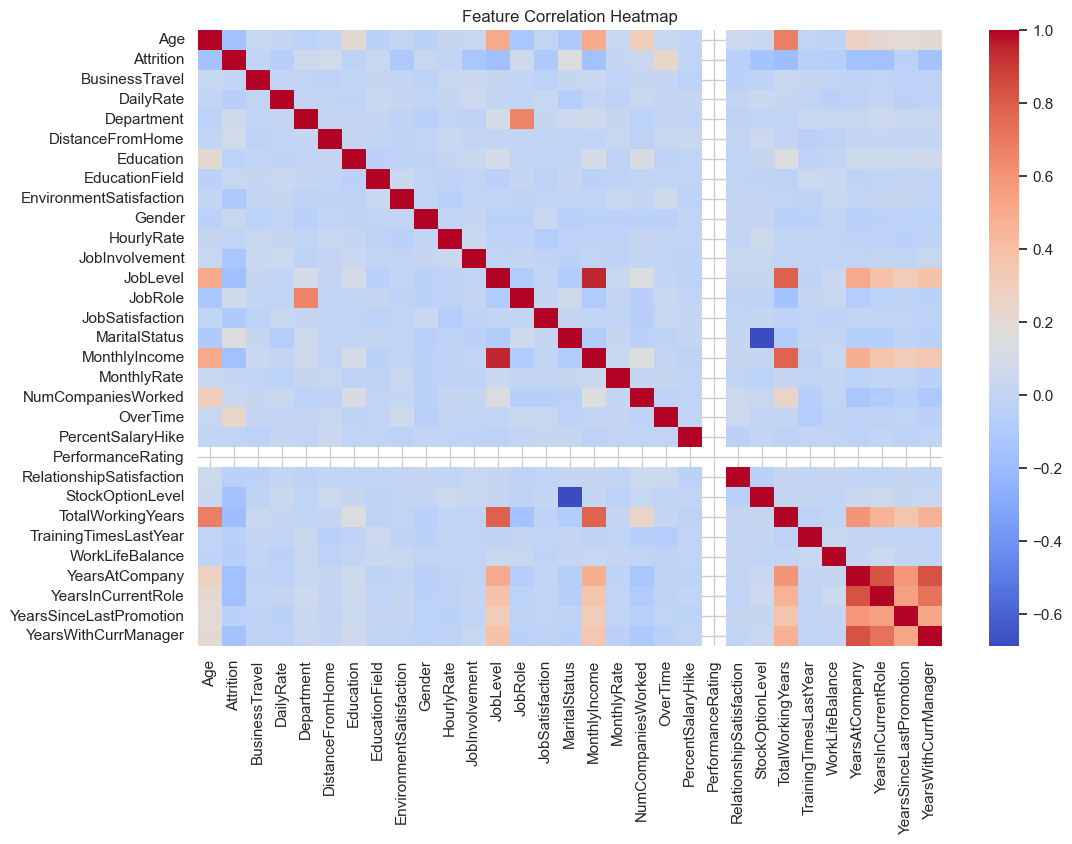

In [62]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

**6.4** 💡 **Insight:** The heatmap reveals feature relationships and potential multicollinearity issues.


**6.5** ❓ **Question:** How is the Logistic Regression model trained?


In [63]:
LogisticRegressionModel = LogisticRegression(penalty='l2',solver='sag',C=1.0,random_state=33)
LogisticRegressionModel.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,33
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


**6.6** 💡 **Insight:** An L2-regularized Logistic Regression model is trained on the SMOTE-resampled training data.


**6.7** ❓ **Question:** What is the model accuracy on train and test sets?


In [64]:
# Accuracy scores
print('Train Accuracy:', LogisticRegressionModel.score(X_train, y_train))
print('Test Accuracy:', LogisticRegressionModel.score(X_test, y_test))

# Predictions
y_pred = LogisticRegressionModel.predict(X_test)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Train Accuracy: 0.8384353741496599
Test Accuracy: 0.8401360544217688

Classification Report:

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       247
           1       0.00      0.00      0.00        47

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.71      0.84      0.77       294



**6.8** 💡 **Insight:** Accuracy scores show how well the model generalizes from training to unseen test data.


**6.9** ❓ **Question:** What does the confusion matrix show?


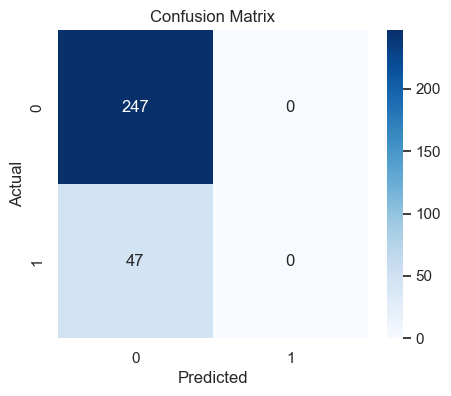

In [65]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**6.10** 💡 **Insight:** Confusion matrix visualizes correct vs incorrect predictions for both classes.


**6.11** ❓ **Question:** What is the ROC curve and AUC score?


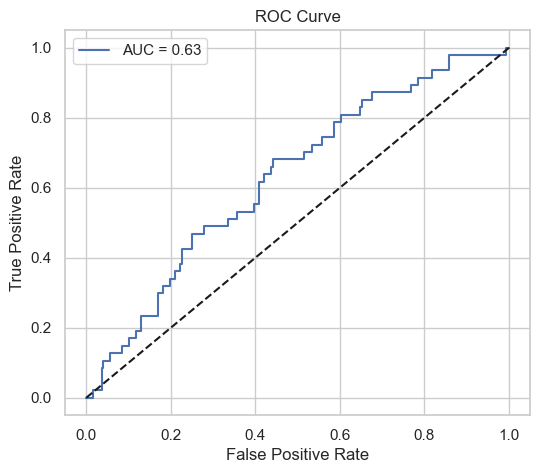

In [66]:
y_prob = LogisticRegressionModel.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**6.12** 💡 **Insight:** AUC quantifies the model's discriminatory power between leavers and stayers.


**6.13** ❓ **Question:** How is the best trained model saved to disk?


In [67]:
import pickle
import os

# Save the Logistic Regression model
os.makedirs("../src/models", exist_ok=True)
with open("../src/models/logistic_regression.pkl", "wb") as f:
    pickle.dump(LogisticRegressionModel, f)

print("Model saved to src/models/logistic_regression.pkl")


Model saved to src/models/logistic_regression.pkl


**6.14** 💡 **Insight:** The trained Logistic Regression model is serialized to `src/model/logistic_regression.pkl` for later inference.


## 🏷 Summary


This machine learning pipeline for predicting employee attrition successfully:

- **Cleaned & preprocessed** the HR dataset by removing redundant columns and encoding categorical variables.
- **Explored** key patterns: younger employees, males, and specific departments show higher attrition risk.
- **Handled imbalance** using SMOTE to create a balanced training set.
- **Trained a Logistic Regression** model with L2 regularization.
- **Evaluated** using accuracy, confusion matrix, and ROC-AUC metrics.

The model provides a baseline for predicting which employees are at risk of leaving, enabling proactive retention strategies.
